# Dimensional Method: CS-01 TAS

**Purpose**: characterise the Tele Assistance System dimensionally for every
adaptation (`baseline`, `s1`, `s2`, `aggregate`). For each artifact, PyDASA
derives Pi-groups from the 10 relevant variables (3 FDUs: `T`, `S`, `D`
meaning Time / Structure / Data), then four operationally meaningful
coefficients are built from them:

- $\theta = L/K$ &nbsp; **Occupancy** (queue fill ratio)
- $\sigma = W\lambda/K$ &nbsp; **Stall** (Little's-law residual; blocking)
- $\eta = \chi K/(\mu c)$ &nbsp; **Effective-yield** (utilisation headroom)
- $\phi = M_{act}/M_{buf}$ &nbsp; **Memory-usage** (buffer fill)

Outputs go under `data/results/dimensional/<scenario>/<profile>.json` and
figures under `data/img/dimensional/<scenario>/`.

**Equivalent CLI**:

```bash
python -m src.methods.dimensional --adaptation baseline
python -m src.methods.dimensional --adaptation s1 --profile opti
python -m src.methods.dimensional --adaptation s2 --profile opti
python -m src.methods.dimensional --adaptation aggregate --profile opti
```


In [11]:
%matplotlib inline

from pathlib import Path

import pandas as pd

from src.dimensional import (compute_coefs_delta,
                             coefs_to_net,
                             coefs_to_nodes,
                             compute_net_delta)
from src.methods.dimensional import run
from src.view import (plot_dim_topology,
                      plot_nd_diffmap,
                      plot_nd_heatmap,
                      plot_net_bars,
                      plot_net_delta)

# adaptation axis for the matrix
ADAPTATIONS = ["baseline", "s1", "s2", "aggregate"]

# figure output root for this method
IMG_ROOT = Path("data/img/dimensional")

# label map for the four derived coefficients (LaTeX-wrapped for plotters)
COEF_LABELS = {
    "theta": r"$\theta$",
    "sigma": r"$\sigma$",
    "eta": r"$\eta$",
    "phi": r"$\phi$",
}


## 1. Run the dimensional method on every adaptation

`run(adp=a, wrt=True)` loads the resolved `NetCfg`, builds one
`AnalysisEngine` per artifact, derives 7 Pi-groups, applies the 4 coefficient
specs from `data/config/method/dimensional.json`, and runs a symbolic
sensitivity pass. Result written to
`data/results/dimensional/<scenario>/<profile>.json`.


In [12]:
results = {a: run(adp=a, wrt=True) for a in ADAPTATIONS}

# unpack the per-adaptation per-node / network frames
nodes = {a: coefs_to_nodes(results[a]) for a in ADAPTATIONS}
nets = {a: coefs_to_net(results[a]) for a in ADAPTATIONS}

for a in ADAPTATIONS:
    cfg = results[a]["config"]
    print(f"{a:>10} -> profile={cfg.profile}  scenario={cfg.scenario}  "
          f"artifacts={len(results[a]['artifacts'])}")


  baseline -> profile=dflt  scenario=baseline  artifacts=13
        s1 -> profile=opti  scenario=s1  artifacts=13
        s2 -> profile=opti  scenario=s2  artifacts=13
 aggregate -> profile=opti  scenario=aggregate  artifacts=13


## 2. Network-wide coefficient summary

One row per adaptation. Aggregation is the **mean** across the 13 (or 16)
artifacts of that scenario; see `coefs_to_net(agg="median")` for
the robust view.


In [13]:
rows = []
for a in ADAPTATIONS:
    row = {"adaptation": a}
    row.update(nets[a].iloc[0].to_dict())
    rows.append(row)

pd.DataFrame(rows).set_index("adaptation")


,nodes,theta,sigma,eta,phi
adaptation,,,,,
baseline,13.0,0.053748,0.053887,1.443769,0.053748
s1,13.0,0.188093,0.071122,1.047663,0.168240
s2,13.0,0.080523,0.080727,0.862677,0.048314
aggregate,13.0,0.080523,0.080727,0.862677,0.048314


## 3. Per-node coefficient snapshot (baseline)

Reference cloud before any adaptation. Under the uniform baseline init
($L_{mean}=6$, $K_{mean}=10$, $M_{act}=L\delta$, $M_{buf}=K\delta$), $\theta$
and $\phi$ collapse to the same value $0.6$ on every artifact. $\sigma$ and
$\eta$ vary with the per-artifact service rate and error probability.


In [14]:
nodes["baseline"][["key", "name", "type", "theta", "sigma", "eta", "phi"]]


,key,name,type,theta,sigma,eta,phi
0,TAS_{1},TAS composite stage 1 (dispatch),M/M/s/K,0.062133,0.062136,1.916667,0.062133
1,TAS_{2},TAS composite stage 2 (medical dispatch),M/M/s/K,0.058621,0.058623,1.848214,0.058621
2,TAS_{3},TAS composite stage 3 (alarm dispatch),M/M/s/K,0.032914,0.032914,1.238180,0.032914
3,MAS_{1},Medical Analysis Service 1,M/M/s/K,0.115719,0.115830,2.371875,0.115719
4,MAS_{2},Medical Analysis Service 2,M/M/s/K,0.020953,0.020953,1.074057,0.020953
5,MAS_{3},Medical Analysis Service 3,M/M/s/K,0.206804,0.208491,2.846250,0.206804
6,AS_{1},Alarm Service 1,M/M/s/K,0.010110,0.010110,0.544799,0.010110
7,AS_{2},Alarm Service 2,M/M/s/K,0.017005,0.017005,0.930145,0.017005
8,AS_{3},Alarm Service 3,M/M/s/K,0.004619,0.004619,0.198686,0.004619
9,TAS_{4},TAS composite stage 4 (drug dispatch),M/M/s/K,0.057698,0.057700,1.829732,0.057698


## 4. Dimensionless topology (per adaptation)

Architecture diagram mirrored from the analytic method, but node colouring
and labels switch to the four dimensionless coefficients
($	heta, \sigma, \eta, \phi$) instead of queue metrics. Node colour
encodes $\sigma$ (Stall, queueing share of capacity); the per-node label
shows the artifact key plus $	heta$ (Occupancy). Full per-node coefficient
table sits below the graph. Every adaptation gets its own topology.png
under data/img/dimensional/<adp>/.


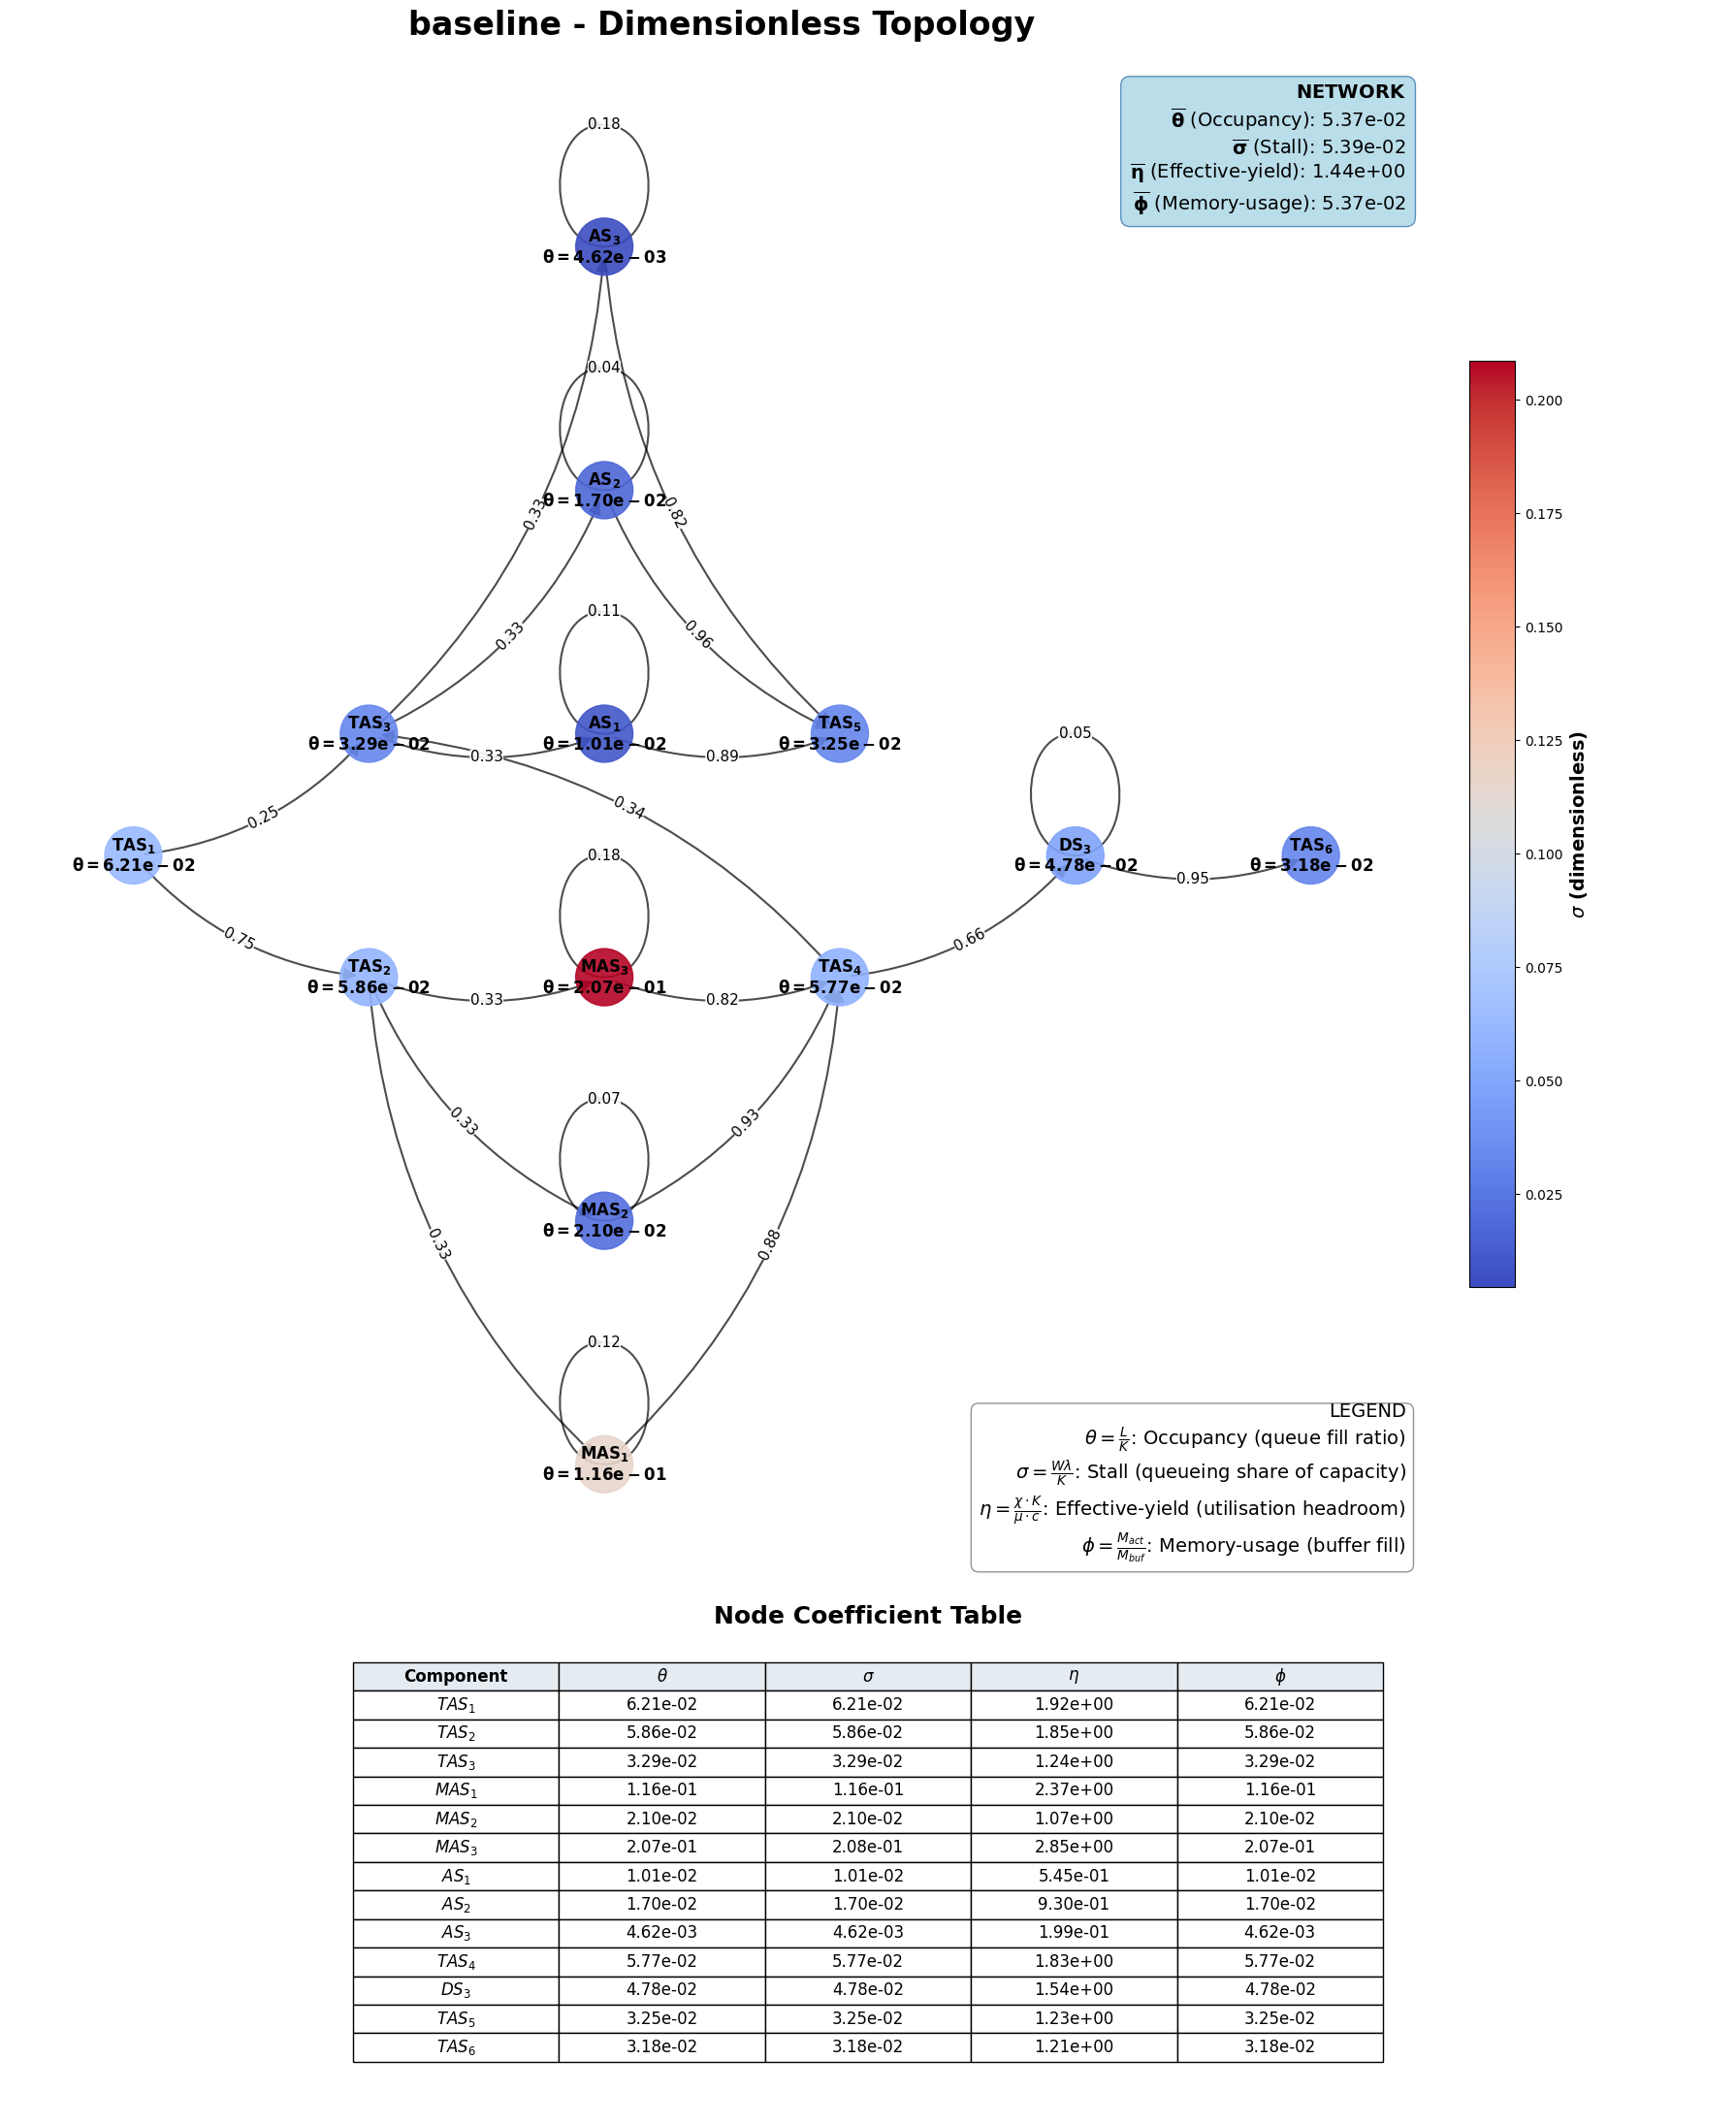

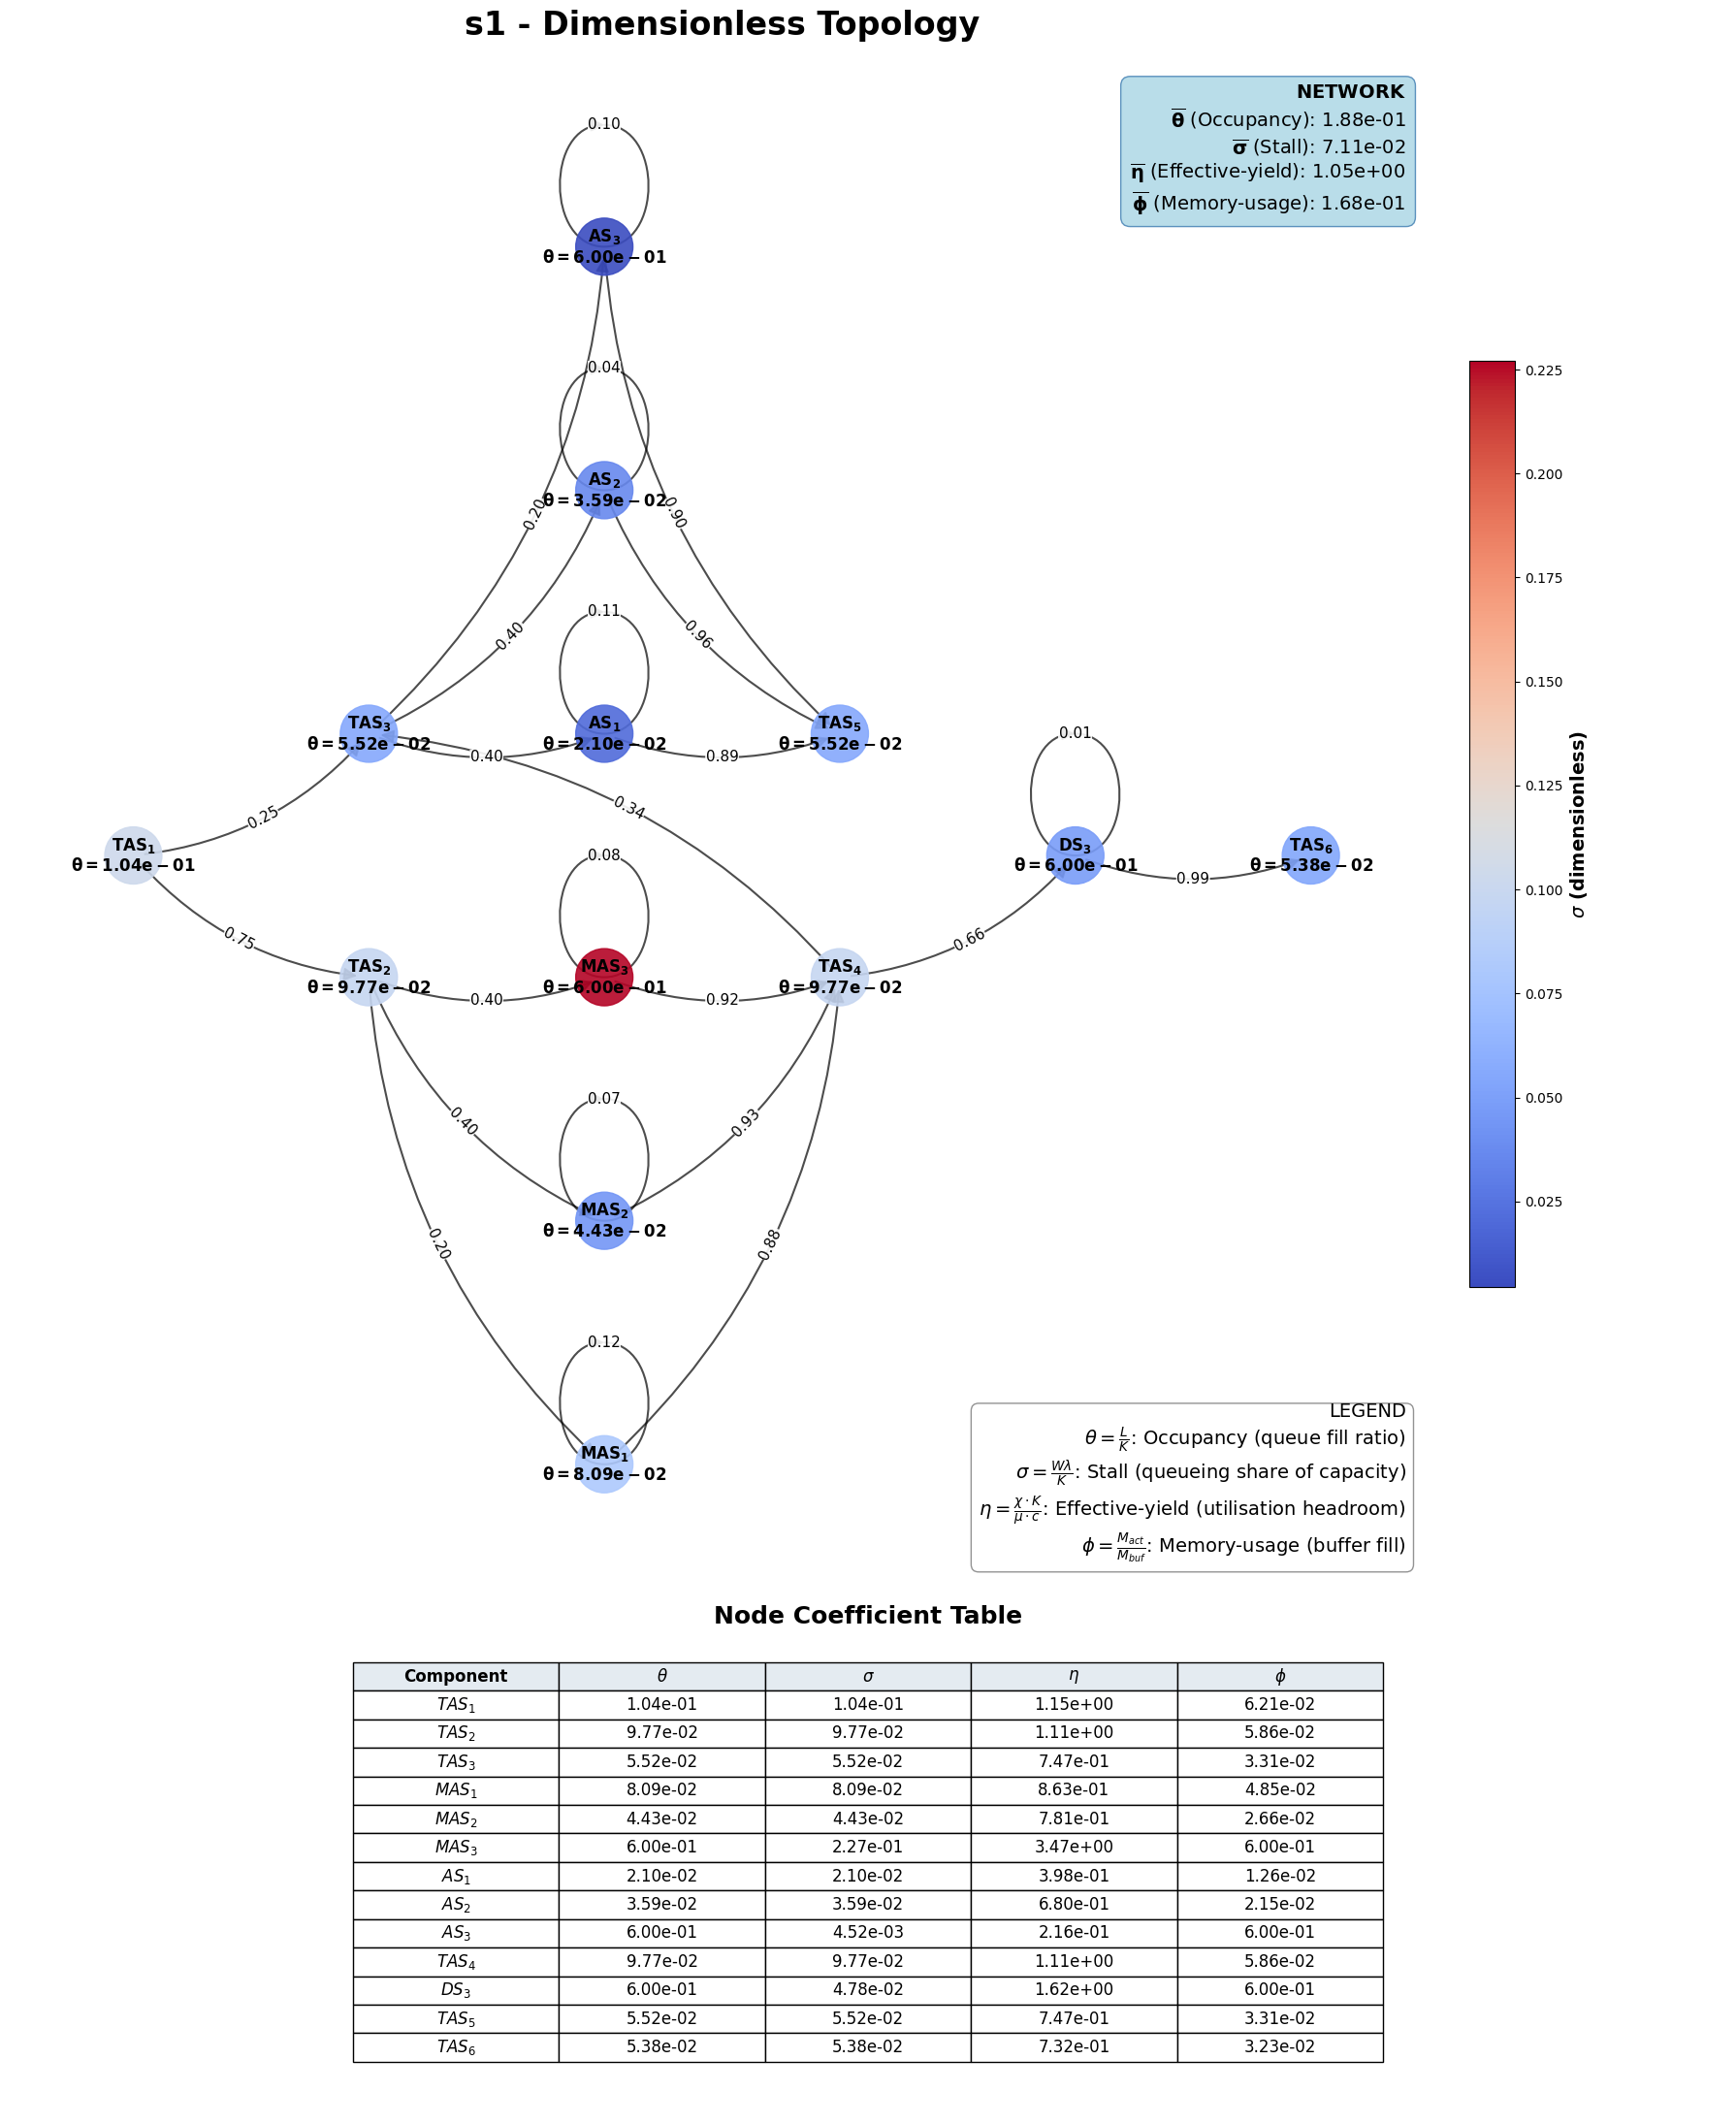

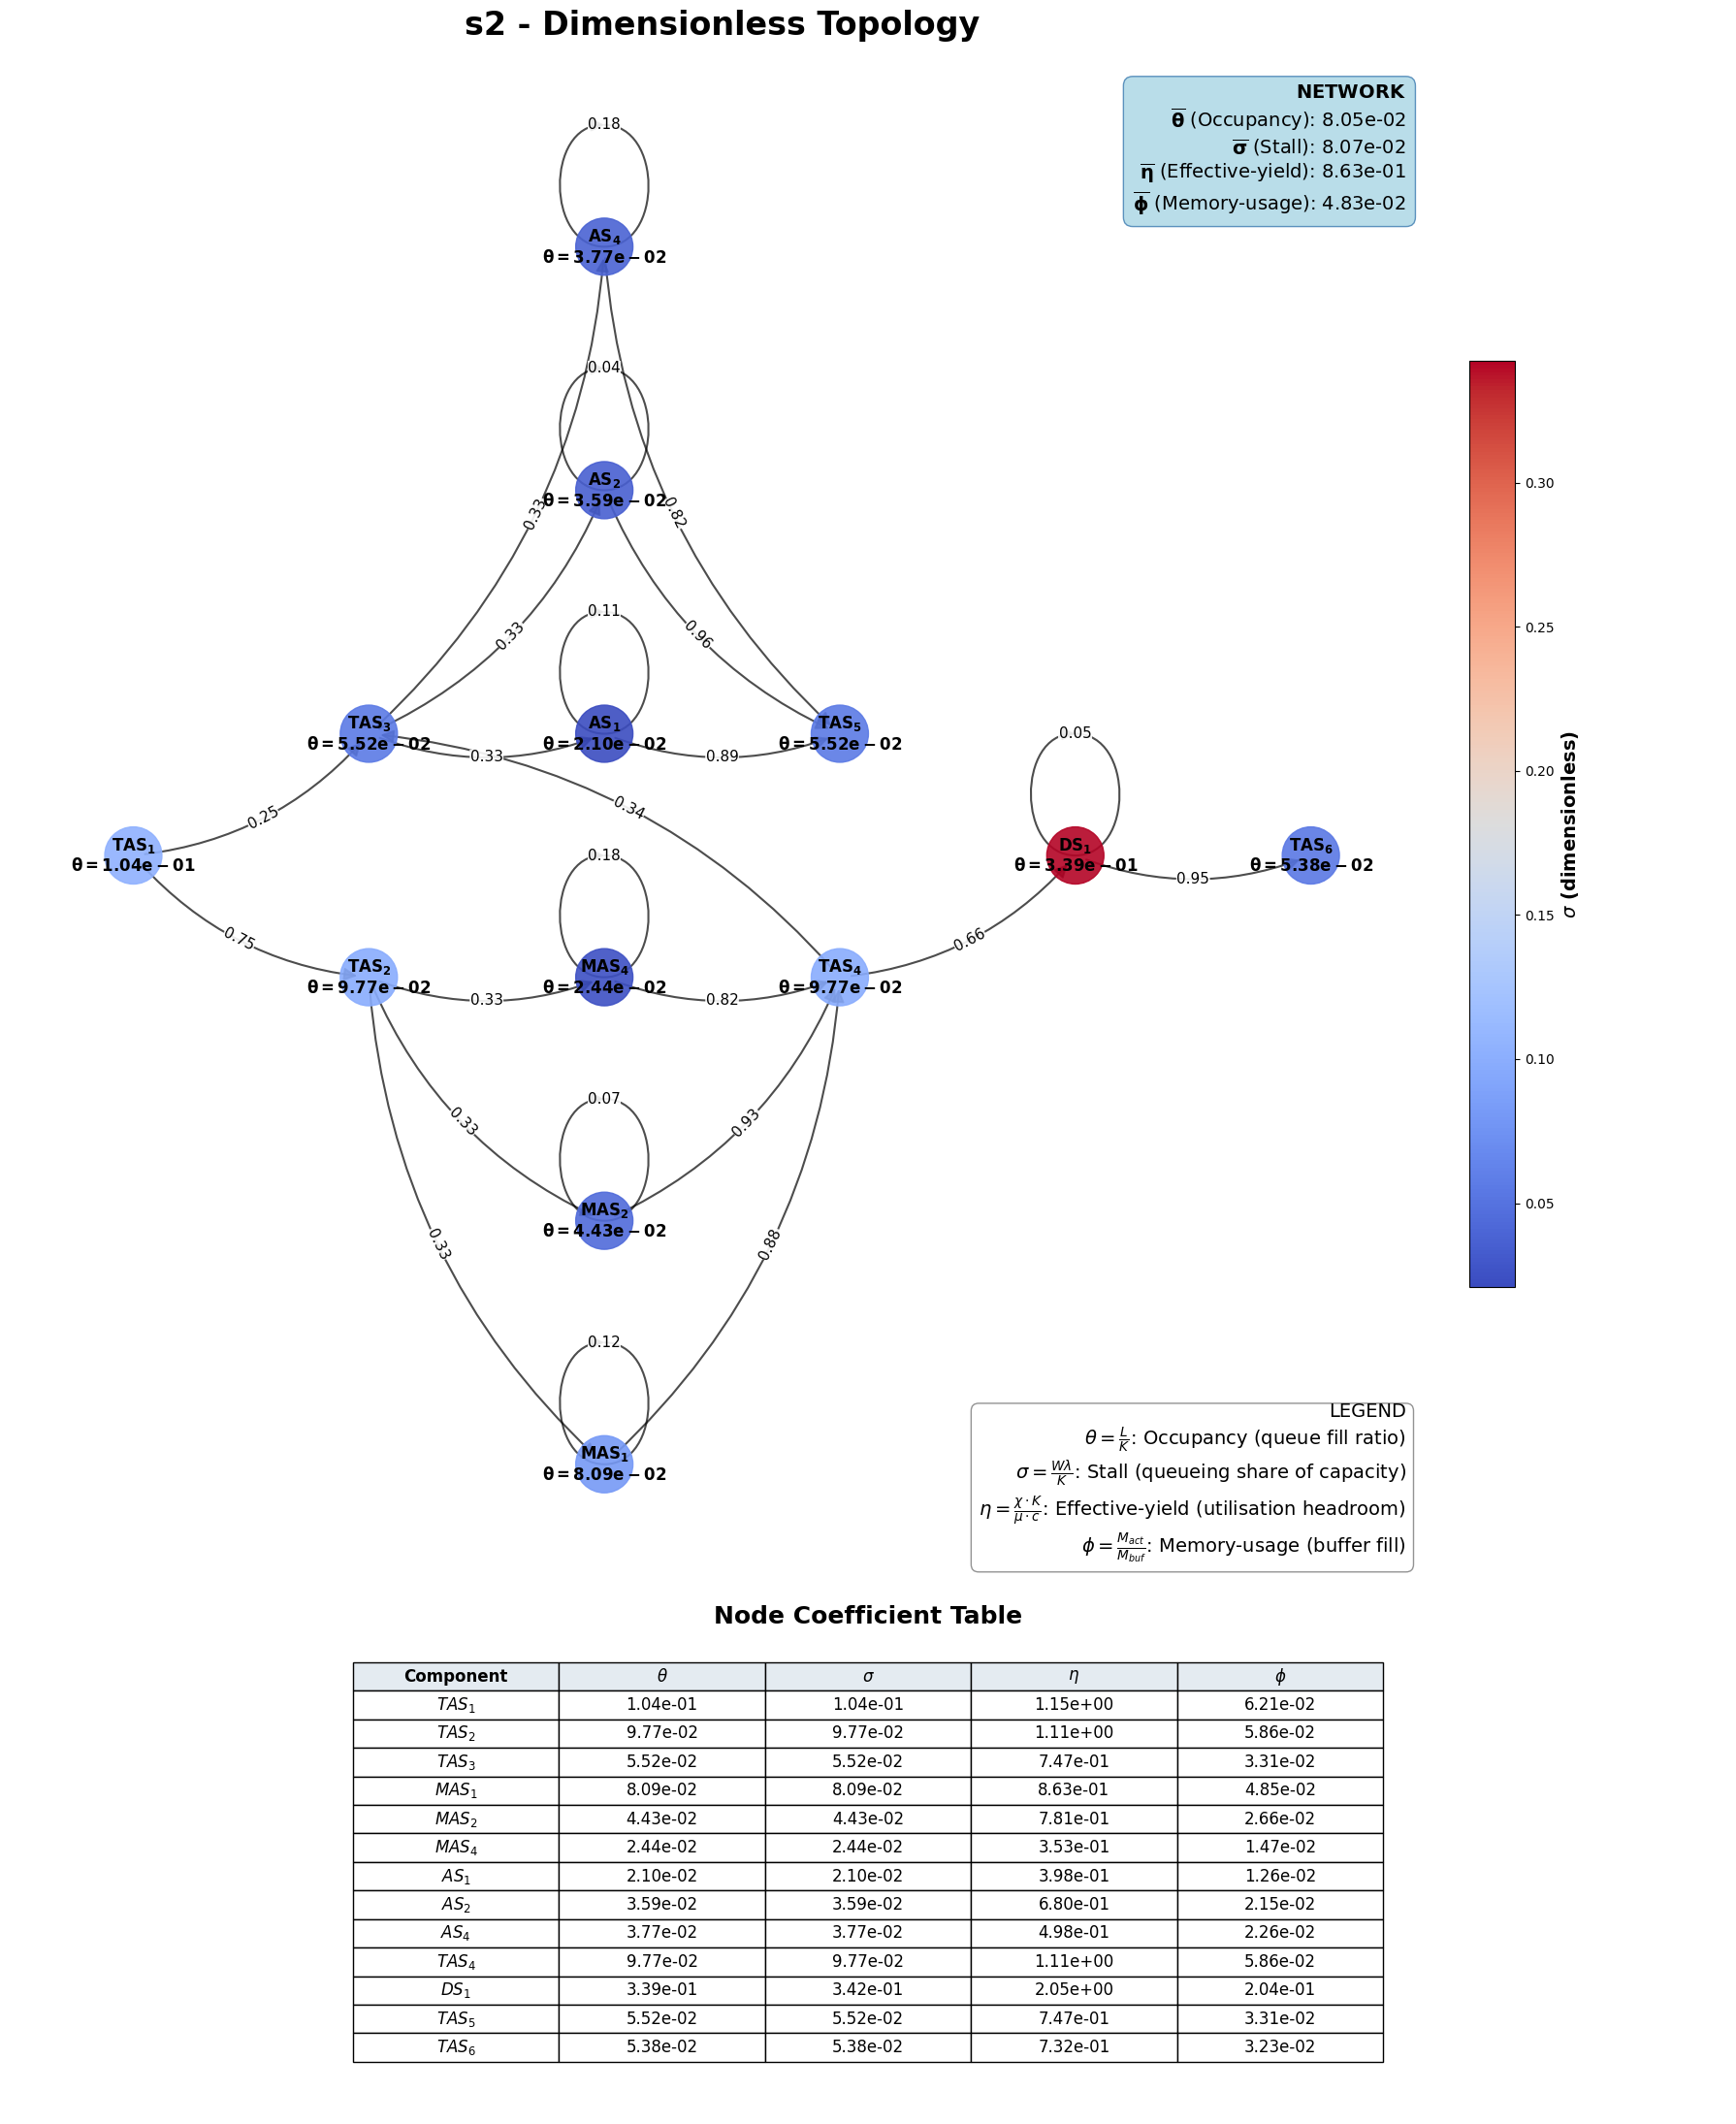

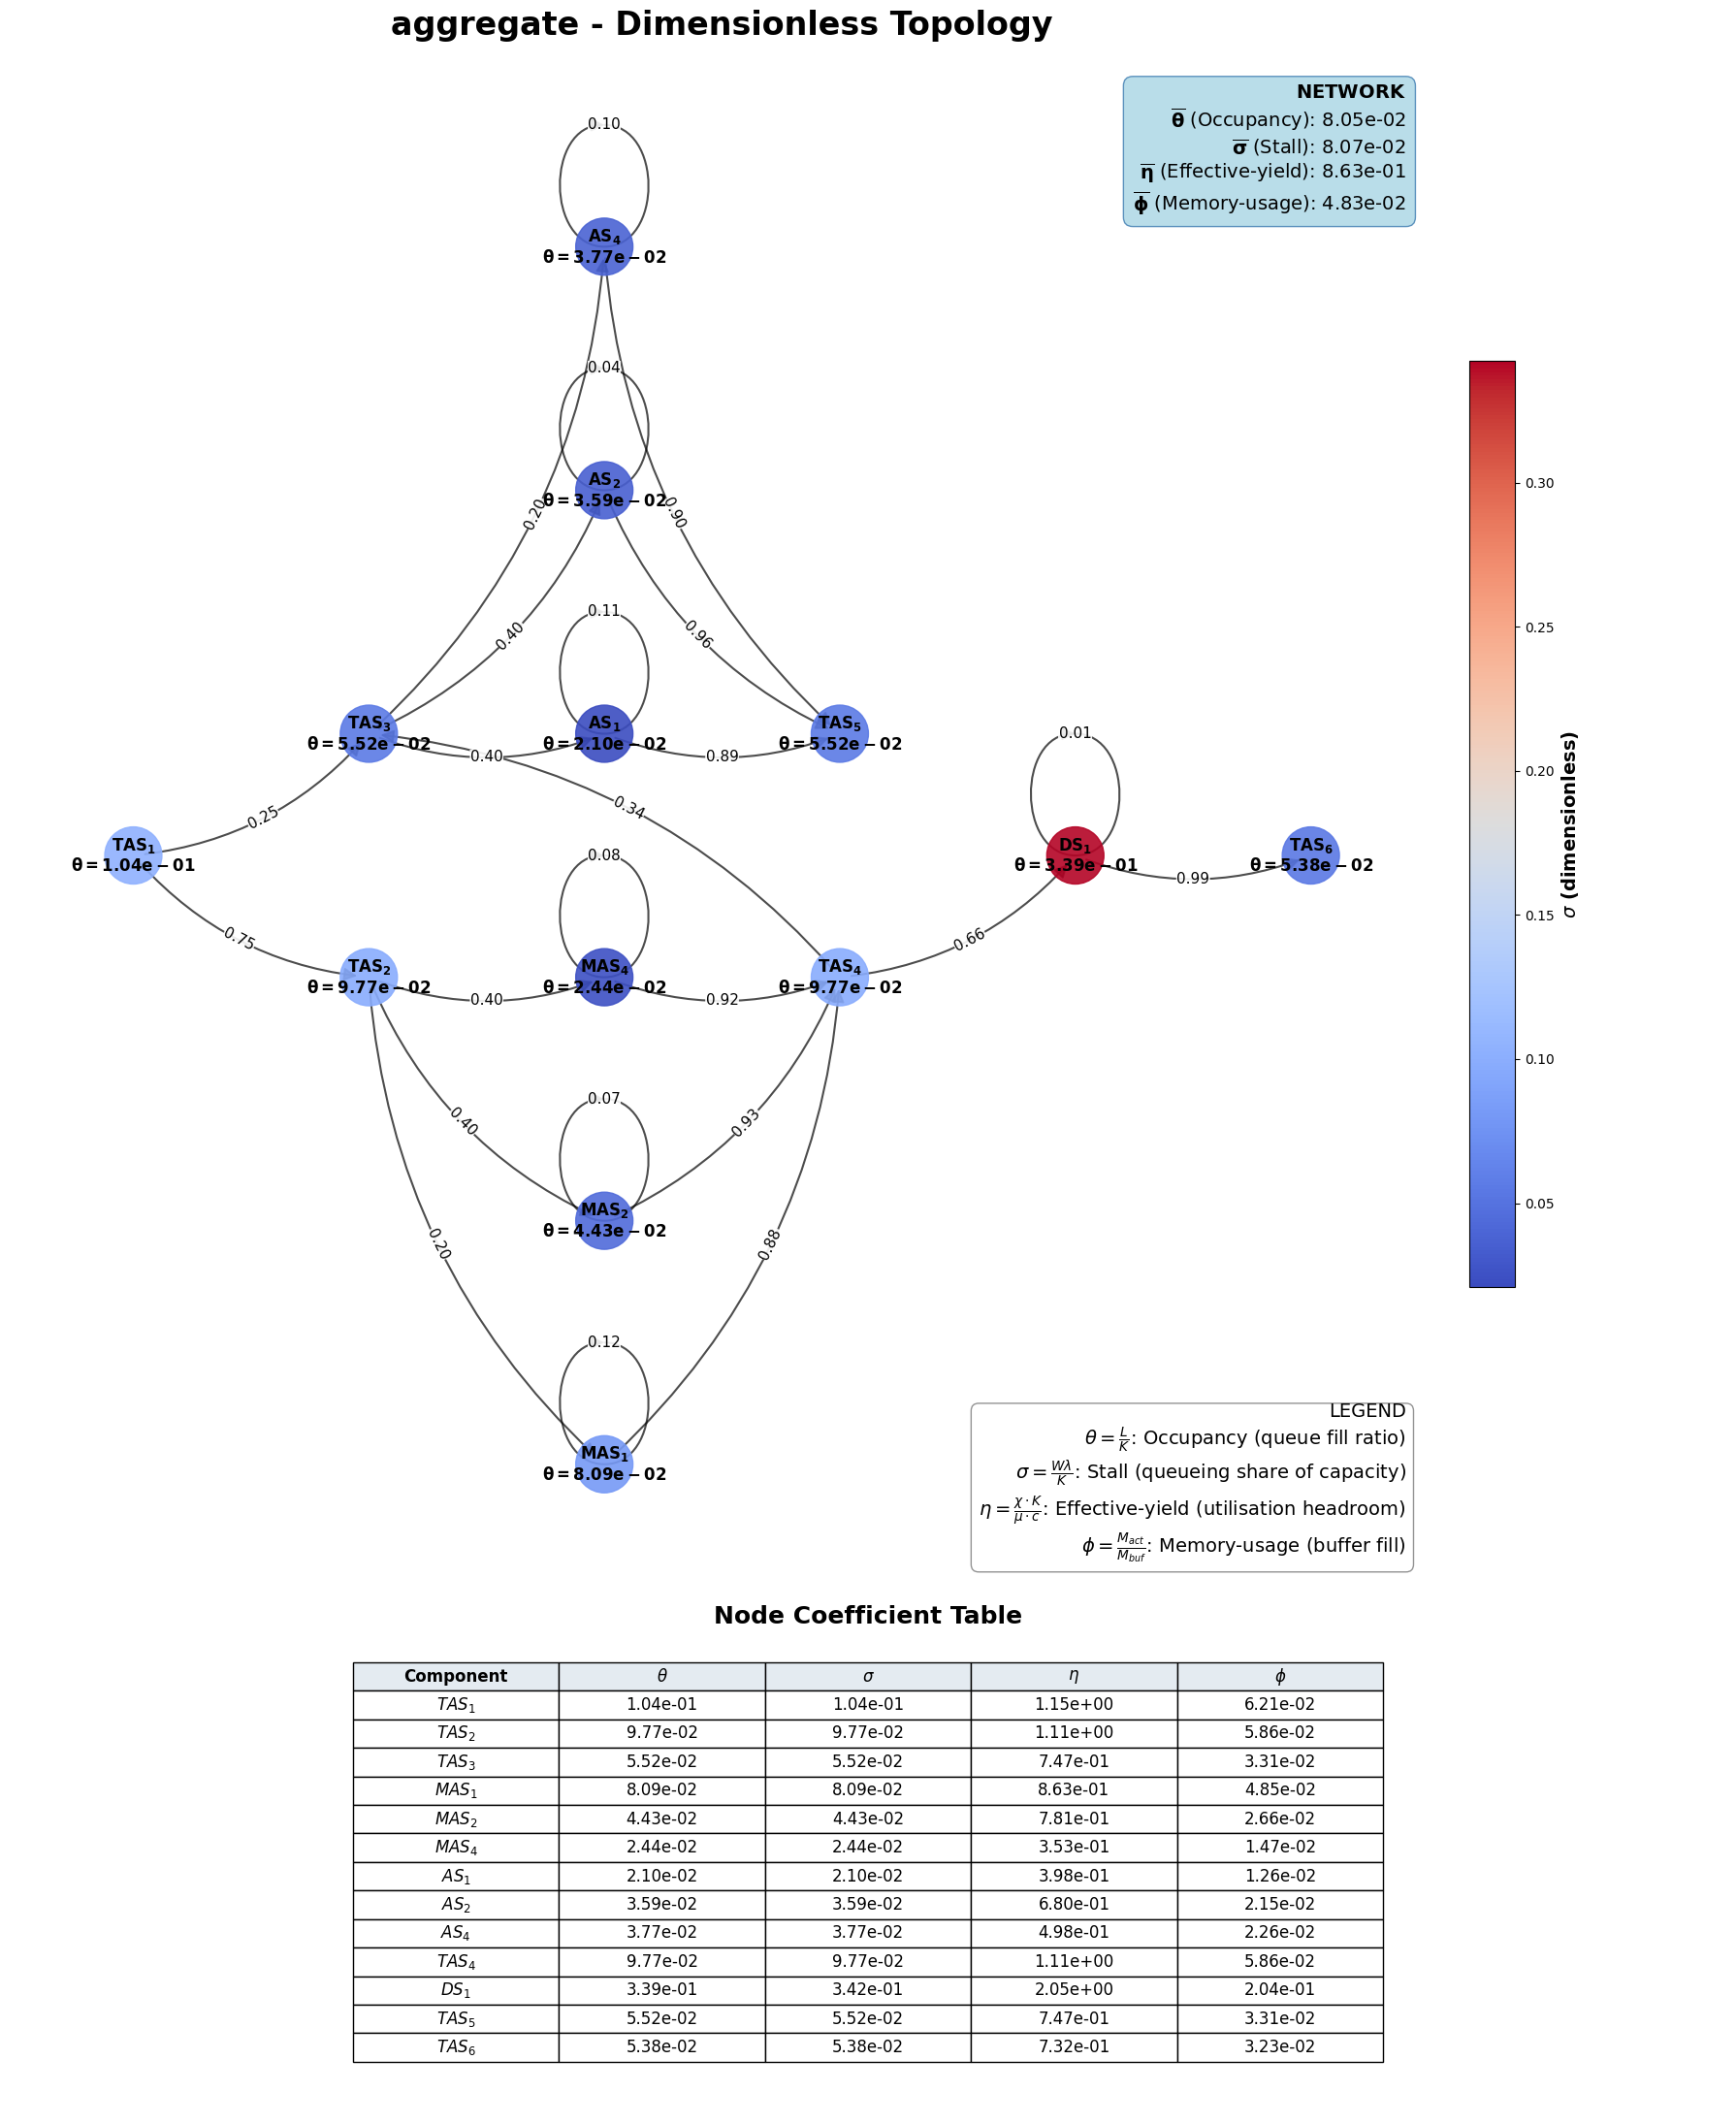

In [15]:
for a in ADAPTATIONS:
    plot_dim_topology(
        rout=results[a]["config"].routing,
        nds=nodes[a],
        color_by="sigma",
        title=f"{a} - Dimensionless Topology",
        file_path=str(IMG_ROOT / a),
        fname="topology.png",
    )


## 5. Per-node coefficient heatmap (before vs after)

One row = one artifact. One column = one coefficient ($\theta$, $\sigma$,
$\eta$, $\phi$). Colour scaled per-column across ALL scenarios so the same
cell is comparable across adaptations. One subplot per adaptation.


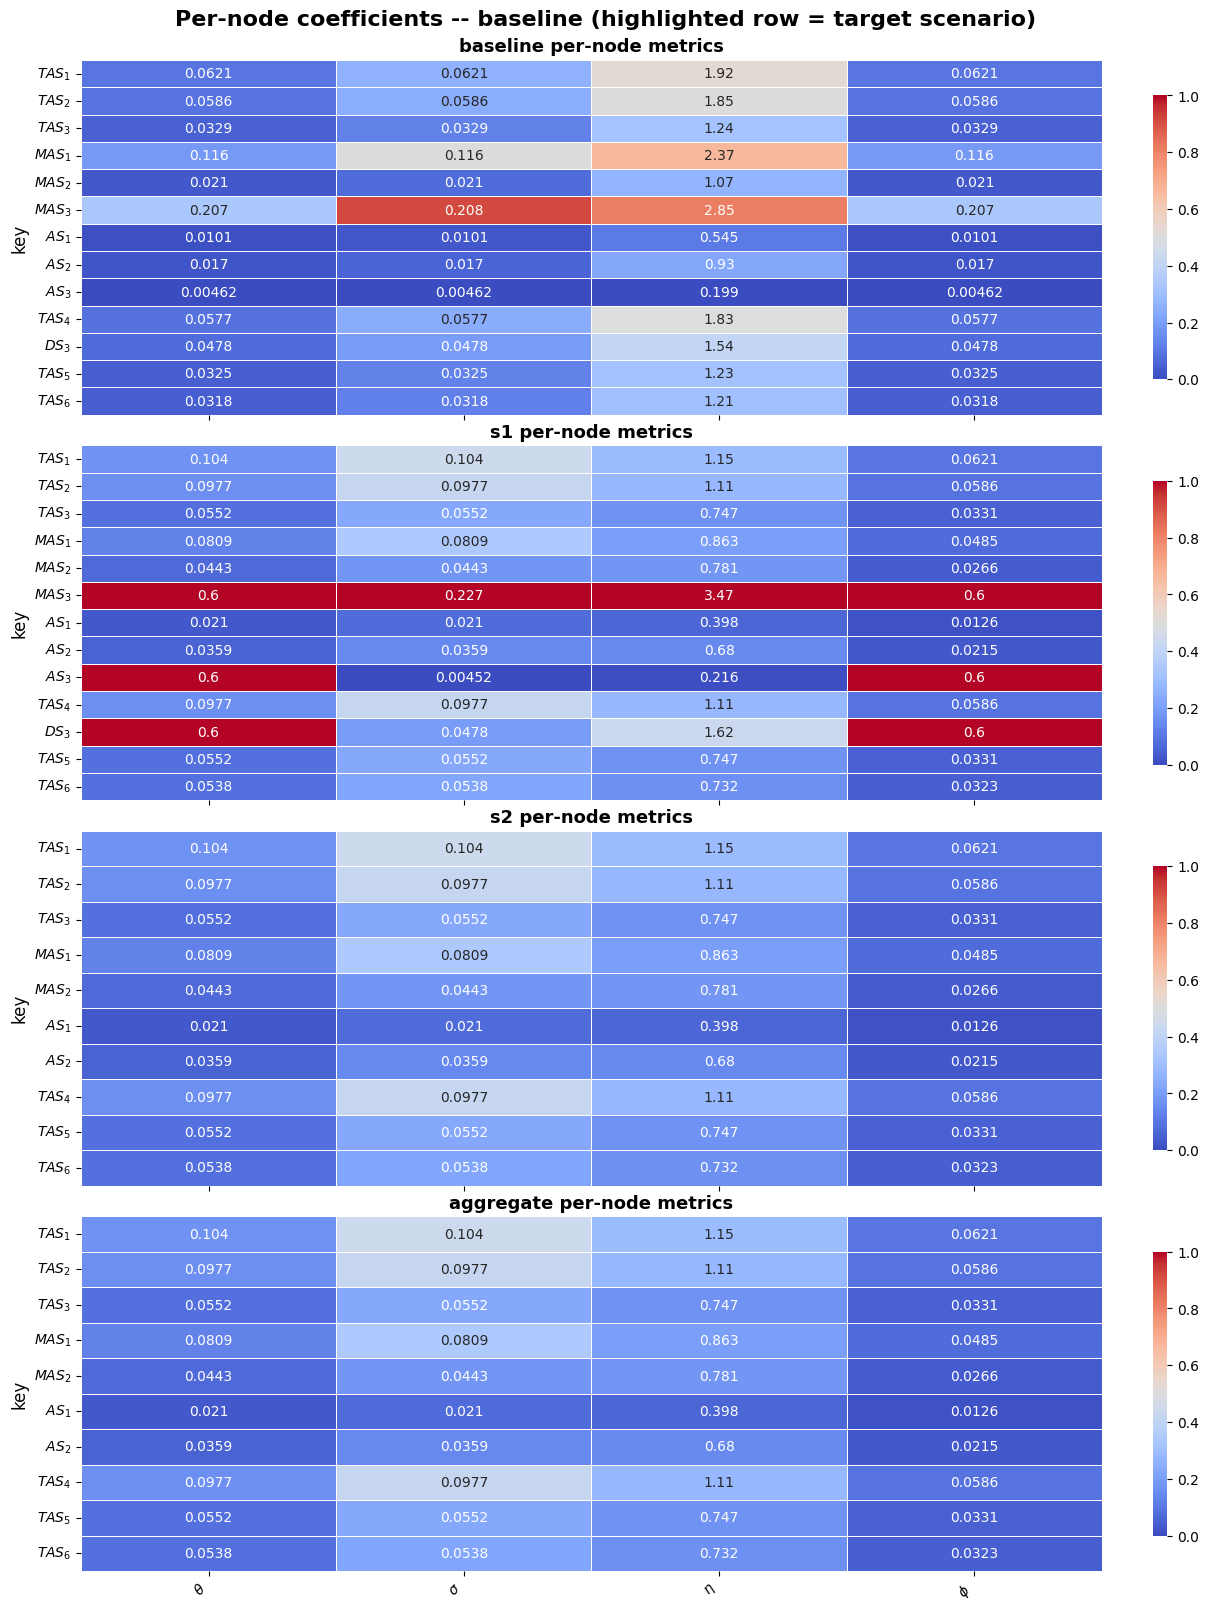

In [16]:
node_keys = nodes["baseline"]["key"].tolist()
heat_metrics = ["theta", "sigma", "eta", "phi"]
heat_labels = [COEF_LABELS[m] for m in heat_metrics]

for a in ADAPTATIONS:
    plot_nd_heatmap(
        [nodes[b] for b in ADAPTATIONS],
        ADAPTATIONS,
        node_keys,
        metrics=heat_metrics,
        labels=heat_labels,
        title=f"Per-node coefficients -- {a} (highlighted row = target scenario)",
        file_path=str(IMG_ROOT / a),
        fname="nd_heatmap.png",
    )
    break  # one figure is enough; the comparison is the same across `a`


## 6. Per-node coefficient diffmap (vs baseline)

For every non-baseline adaptation, show the relative change
$(\text{other} - \text{dflt}) / |\text{dflt}|$ per artifact. Diverging
colour scale, zero-centred so improvements and degradations read with equal
intensity.


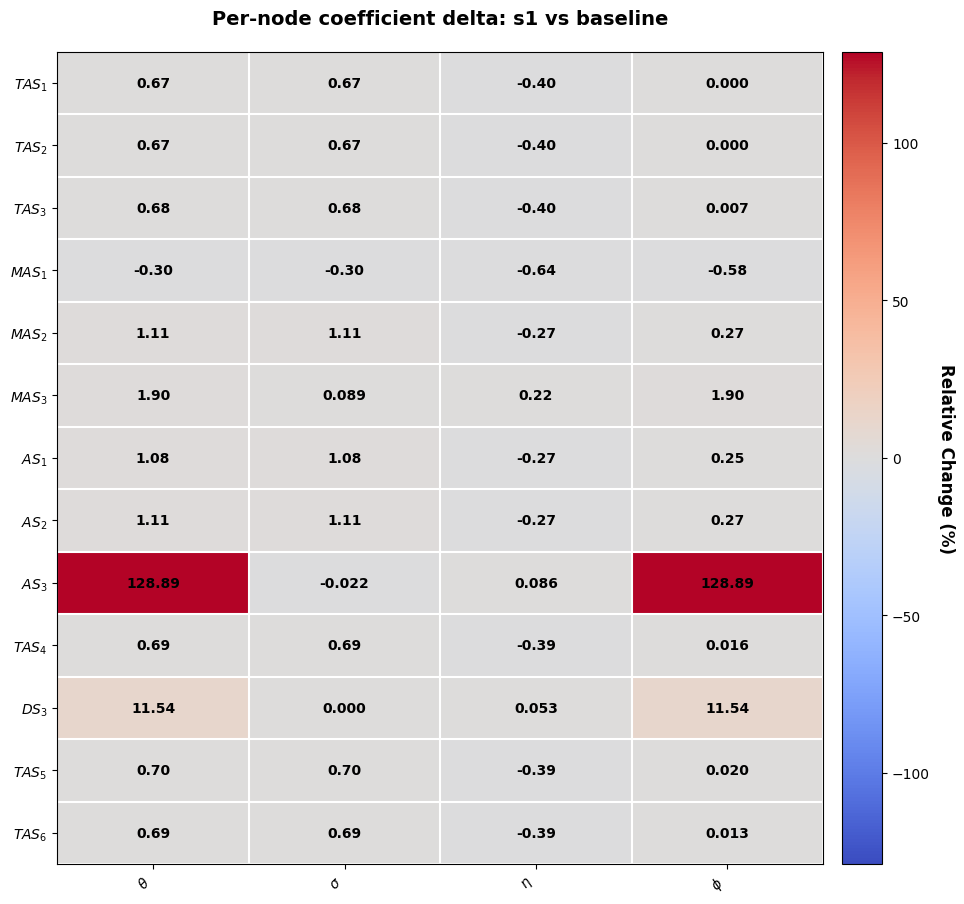

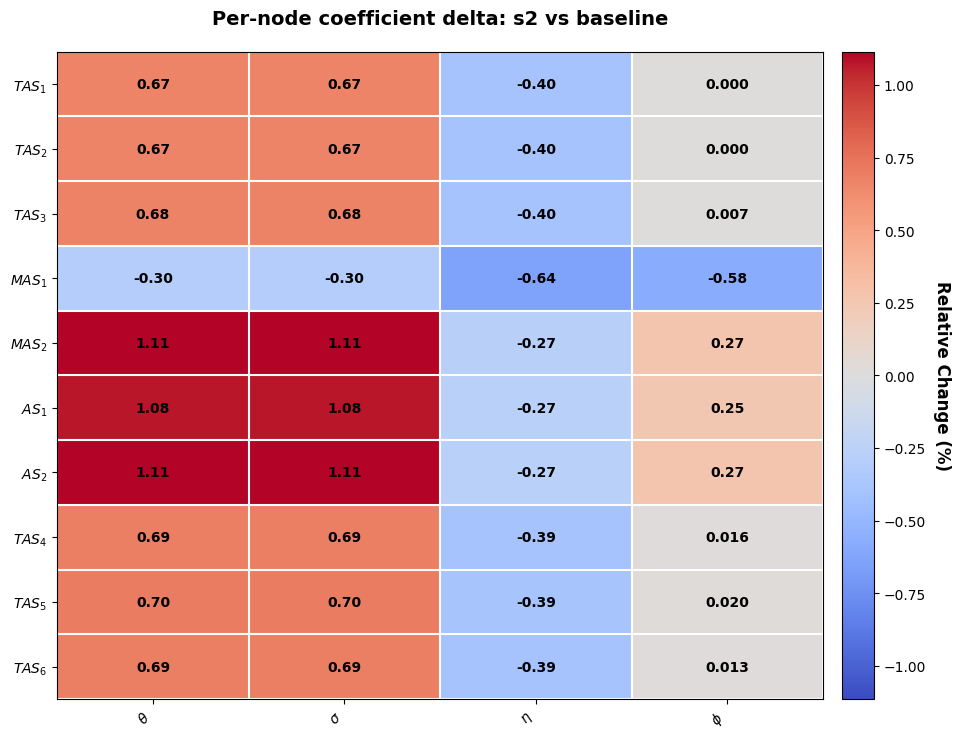

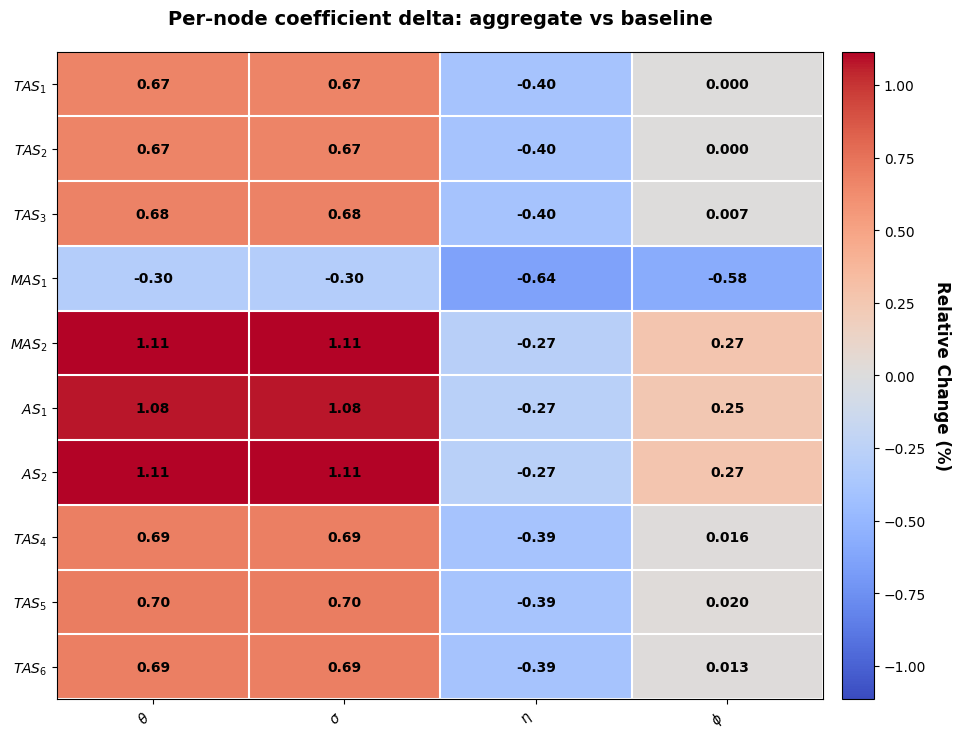

In [17]:
for a in ("s1", "s2", "aggregate"):
    deltas = compute_coefs_delta(nodes["baseline"], nodes[a])

    plot_nd_diffmap(
        deltas,
        node_keys,
        metrics=heat_metrics,
        labels=heat_labels,
        title=f"Per-node coefficient delta: {a} vs baseline",
        file_path=str(IMG_ROOT / a),
        fname="nd_diffmap_vs_baseline.png",
    )


## 7. Network-wide coefficient bars

Headline comparison of the four coefficients across all four adaptations.
Linear y-axis (coefficients are O(1)); log scale would be misleading.


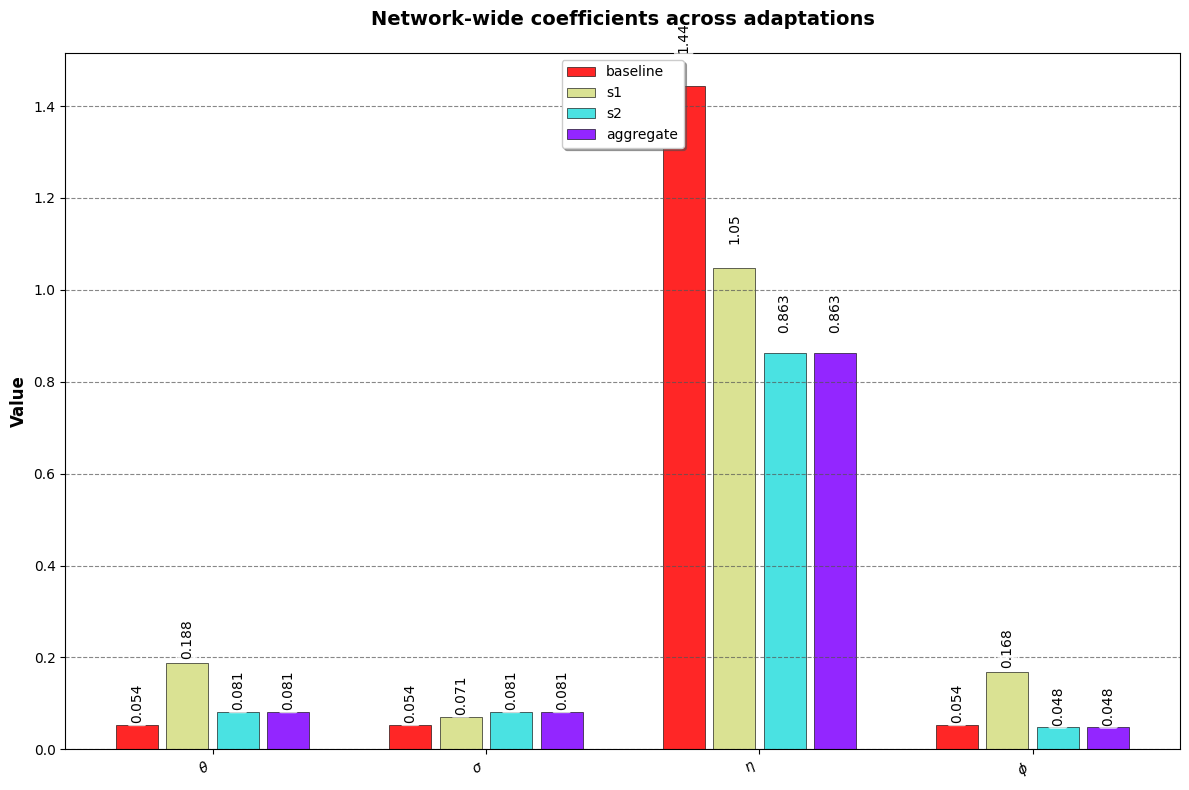

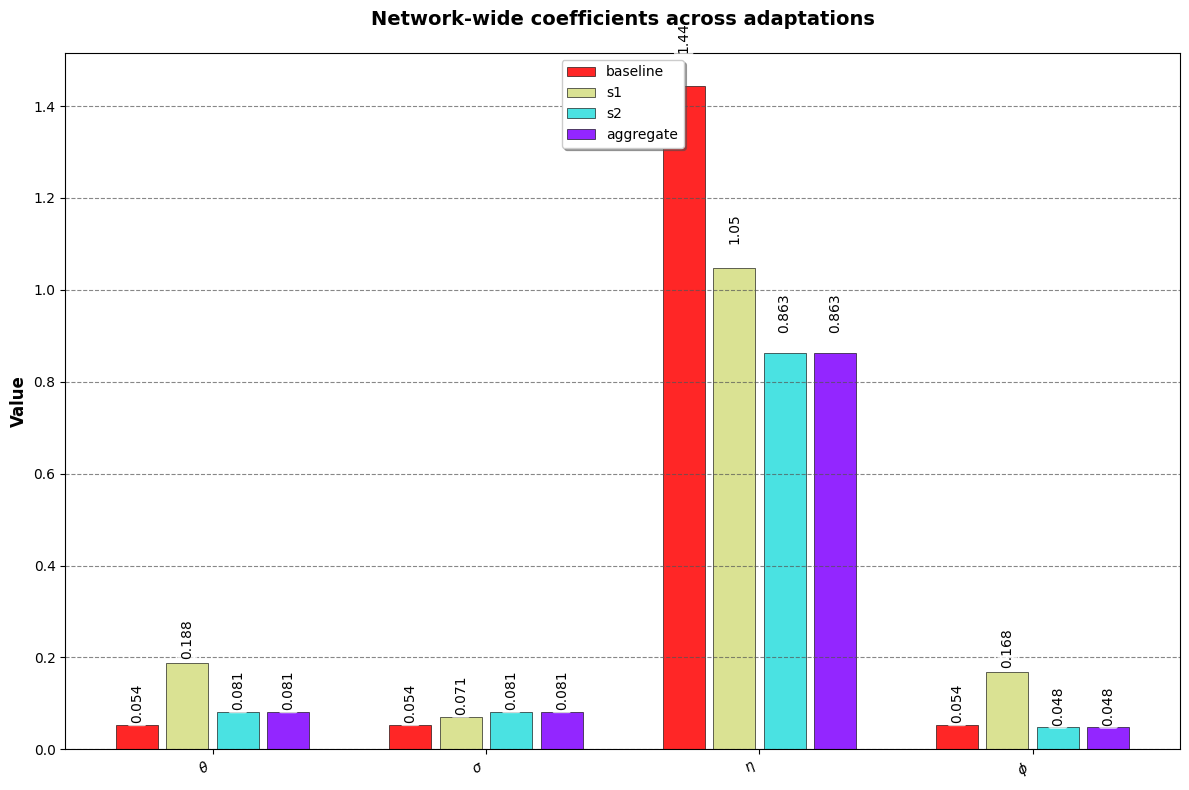

In [18]:
bar_metrics = ["theta", "sigma", "eta", "phi"]
bar_labels = [COEF_LABELS[m] for m in bar_metrics]

plot_net_bars(
    nets=[nets[a] for a in ADAPTATIONS],
    names=ADAPTATIONS,
    metrics=bar_metrics,
    labels=bar_labels,
    logscale=False,
    title="Network-wide coefficients across adaptations",
    file_path=str(IMG_ROOT / "aggregate"),
    fname="net_bars_all.png",
)


## 8. Network-wide delta (% change vs baseline)

Fractional change for each non-baseline adaptation. Colours semantic: green
when the coefficient decreases (generally an improvement: less occupancy,
less stall, less buffer pressure); red when it increases.


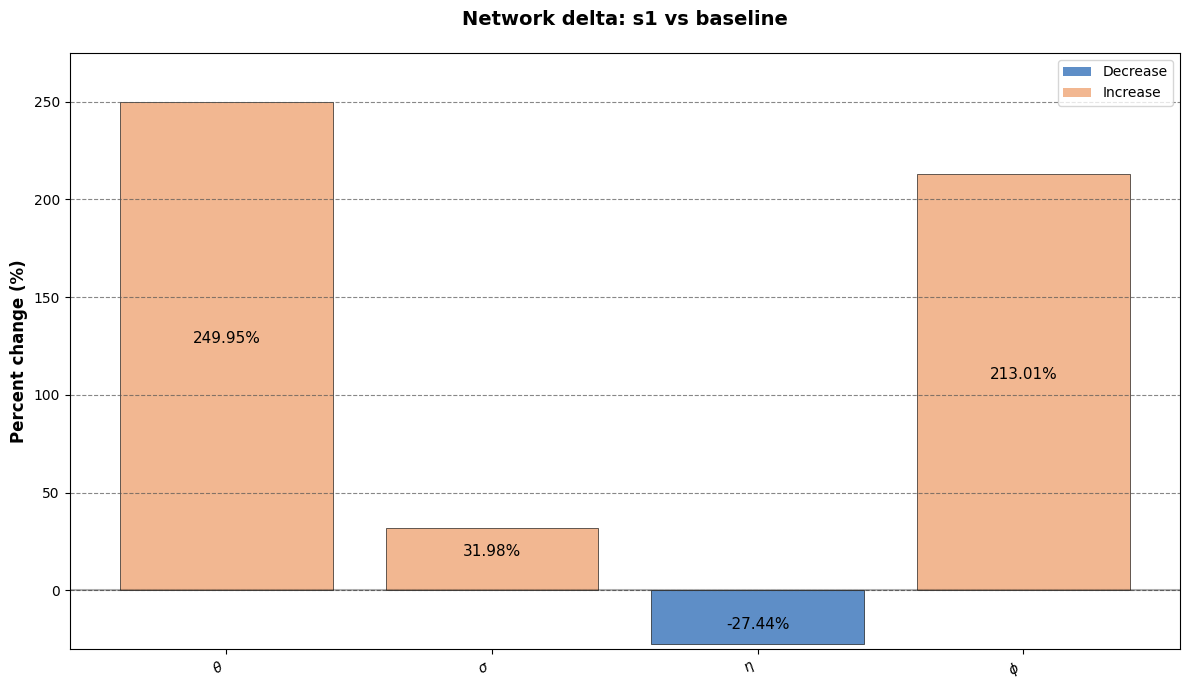

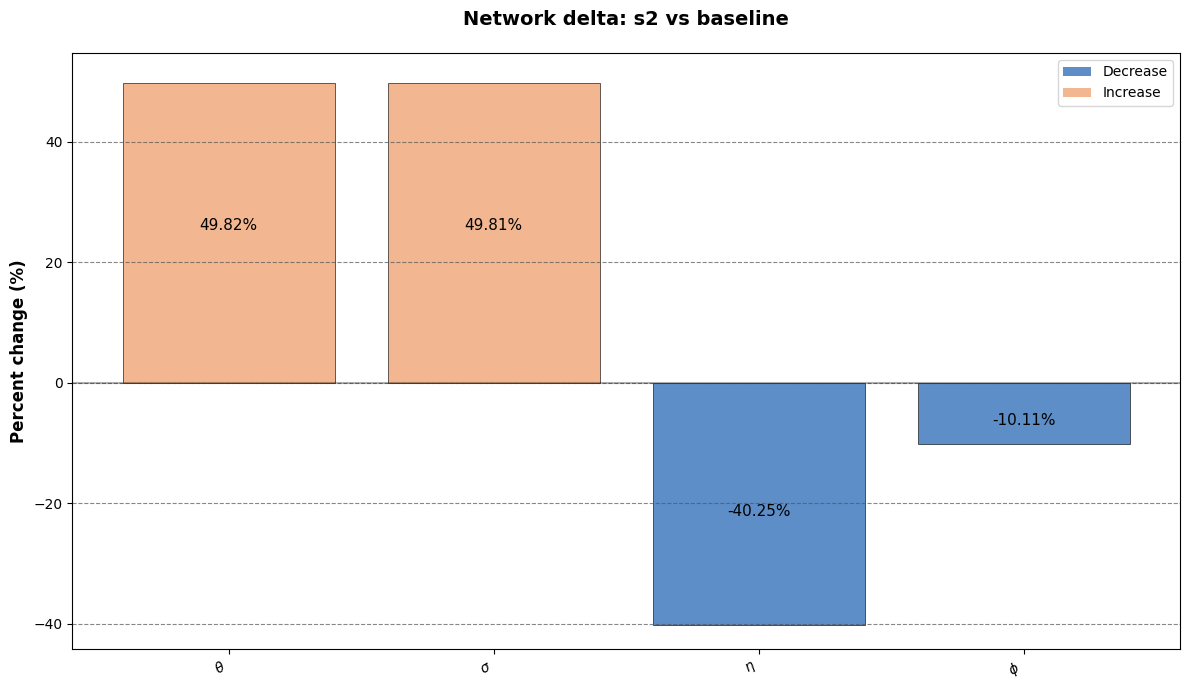

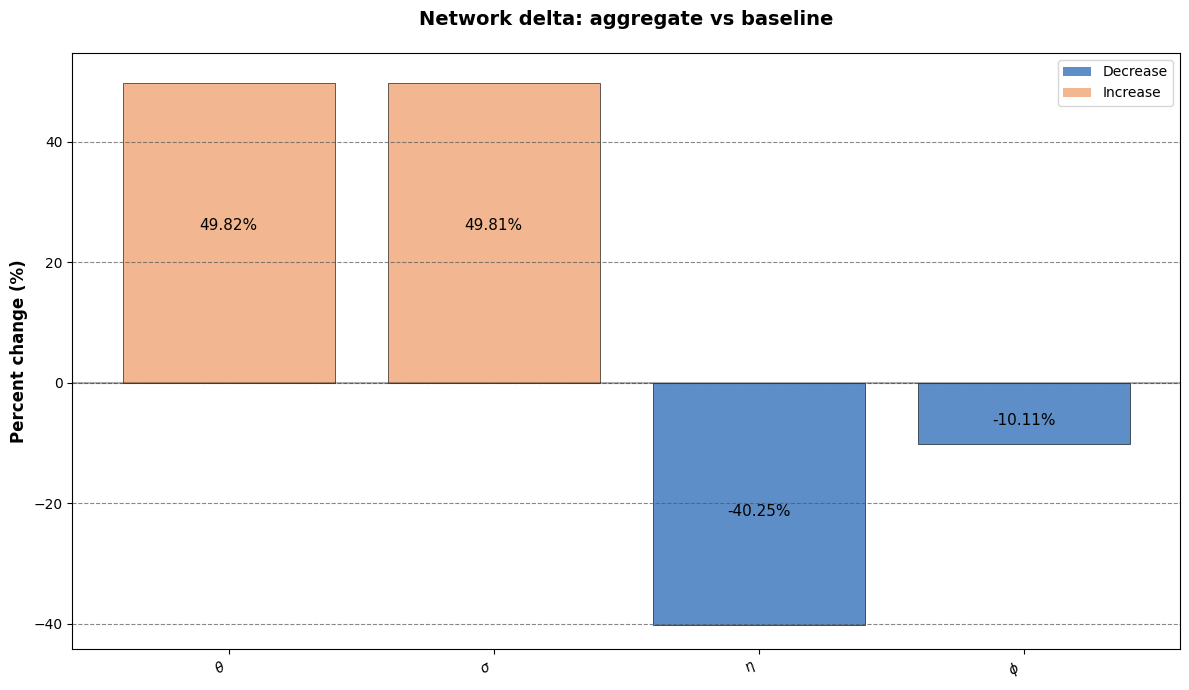

In [19]:
for a in ("s1", "s2", "aggregate"):
    d = compute_net_delta(nets["baseline"], nets[a])

    plot_net_delta(
        d,
        metrics=bar_metrics,
        labels=bar_labels,
        title=f"Network delta: {a} vs baseline",
        file_path=str(IMG_ROOT / a),
        fname="net_delta_vs_baseline.png",
    )


## 9. Top-3 most sensitive variables per coefficient (baseline)

Symbolic sensitivity at variable means. For each coefficient we show the
three variables with the largest $|\partial \text{coeff} / \partial x|$ on
the baseline $TAS_{1}$ artifact. Orientation (sign) is documented in
`notes/workflow.md`.


In [20]:
SAMPLE_ARTIFACT = "TAS_{1}"
sens = results["baseline"]["artifacts"][SAMPLE_ARTIFACT]["sensitivity"]

DERIVED_COEFFS = [
    (r"$\theta$", "SEN_{\\theta_{TAS_{1}}}"),
    (r"$\sigma$", "SEN_{\\sigma_{TAS_{1}}}"),
    (r"$\eta$", "SEN_{\\eta_{TAS_{1}}}"),
    (r"$\phi$", "SEN_{\\phi_{TAS_{1}}}"),
]

sens_rows = []
for label, key in DERIVED_COEFFS:
    vmap = sens.get(key, {})
    top3 = sorted(vmap.items(),
                   key=lambda kv: abs(kv[1]),
                   reverse=True)[:3]
    for v_sym, val in top3:
        sens_rows.append({
            "coefficient": label,
            "variable": v_sym,
            "d(coeff)/d(var)": val,
        })

pd.DataFrame(sens_rows)


,coefficient,variable,d(coeff)/d(var)
0,$\theta$,L_{TAS_{1}},0.100000
1,$\theta$,K_{TAS_{1}},-0.006213
2,$\sigma$,W_{TAS_{1}},34.500000
3,$\sigma$,K_{TAS_{1}},-0.006214
4,$\sigma$,\lambda_{TAS_{1}},0.000180
5,$\eta$,c_{TAS_{1}},-0.958333
6,$\eta$,K_{TAS_{1}},0.191667
7,$\eta$,\chi_{TAS_{1}},0.005556
8,$\phi$,M_{act_{TAS_{1}}},0.000094
9,$\phi$,M_{buf_{TAS_{1}}},-0.000006


## Summary

Dimensional analysis produces the same four derived coefficients per
artifact under every adaptation. **Pi-group expressions are invariant**
across adaptations (same variable set, different setpoints); this is the
Buckingham guarantee.

The dimensional method does **not** produce R1 / R2 / R3 verdicts: those are
operational thresholds (failure rate / response time / cost) and belong to
`analytic` and `stochastic`. `comparison.ipynb` will triangulate the three
methods in the last notebook of the pipeline.

Configuration-sweep yoly diagrams (showing the full coefficient cloud across
a $(\mu, c, K)$ grid) live in `yoly.ipynb`; Phase 3b/c of the build plan.
